# Crypto Portfolio Risk Model

## Statistical Metrics:
- Mean Return
- Standard Deviation (Volatility)
- Correlation
- Covariance

## Risk Metrics:
- Daily Returns
- Sharpe Ratio
- Max Drawdown
- VaR / CVaR (95%)
- Backtesting (VaR breaches)
- Kupiec Test (LR statistic, p-value)
- Traffic Light System

## Data Preparation and Daily Returns

In this section, I prepare the dataset and calculate daily returns for BTC, ETH, and BNB.

Daily returns show the percentage change in asset prices from one observation to the next.

This step is important because daily returns are the foundation for key risk metrics such as volatility, Sharpe ratio, Value at Risk (VaR), and backtesting.

The first return value is NaN because there is no previous observation available for comparison.

In [49]:
import pandas as pd
import numpy as np

data = {
    "BTC": [64200, 65100, 64800, 66000, 67500, 66800, 68200, 67900, 68500, 69200],
    "ETH": [3120, 3180, 3150, 3210, 3250, 3220, 3290, 3270, 3310, 3350],
    "BNB": [np.nan, 600, 610, 620, 615, 630, 640, 645, 650, 700]
}

df = pd.DataFrame(data)

df["BTC_return"] = df["BTC"].pct_change()
df["ETH_return"] = df["ETH"].pct_change()
df["BNB_return"] = df["BNB"].pct_change()

df

,BTC,ETH,BNB,BTC_return,ETH_return,BNB_return
0,64200,3120,NaN,NaN,NaN,NaN
1,65100,3180,600.0,0.014019,0.019231,NaN
2,64800,3150,610.0,-0.004608,-0.009434,0.016667
3,66000,3210,620.0,0.018519,0.019048,0.016393
4,67500,3250,615.0,0.022727,0.012461,-0.008065
5,66800,3220,630.0,-0.010370,-0.009231,0.024390
6,68200,3290,640.0,0.020958,0.021739,0.015873
7,67900,3270,645.0,-0.004399,-0.006079,0.007812
8,68500,3310,650.0,0.008837,0.012232,0.007752
9,69200,3350,700.0,0.010219,0.012085,0.076923


## Correlation Analysis

In this section, I analyze the relationship between BTC, ETH, and BNB returns using a correlation matrix.

Correlation measures how strongly assets move together.

A value close to 1 indicates a strong positive relationship, while a value close to 0 suggests a weak relationship.

From the results:

- BTC and ETH show a strong positive correlation (0.93), meaning they tend to move together.
- BTC and BNB have a weak negative correlation (-0.12), suggesting slight opposite movement.
- ETH and BNB show very weak correlation (0.05), indicating almost no strong relationship.

Overall, BTC and ETH are highly correlated, while BNB provides diversification benefits due to its lower correlation with both assets.

In [50]:
df["BTC_return"] = df["BTC"].pct_change()
df["ETH_return"] = df["ETH"].pct_change()
df["BNB_return"] = df["BNB"].pct_change()

In [51]:
corr_matrix = df[["BTC_return", "ETH_return", "BNB_return"]].corr()
corr_matrix.round(2)

,BTC_return,ETH_return,BNB_return
BTC_return,1.00,0.93,-0.12
ETH_return,0.93,1.00,0.05
BNB_return,-0.12,0.05,1.00


## Covariance Analysis

In this section, I analyze how BTC, ETH, and BNB returns move together using a covariance matrix.

Covariance measures whether assets tend to move in the same or opposite direction.

A positive value indicates that assets generally move together, while a negative value suggests opposite movement.

From the covariance matrix:

- BTC and ETH show positive covariance (0.00014), confirming a strong relationship between the two assets.
- BTC and BNB have slight negative covariance (-0.00004), indicating occasional opposite movement.
- ETH and BNB show weak positive covariance (0.00002), suggesting a limited relationship.

Overall, BTC and ETH move closely together, while BNB behaves more independently, which may improve portfolio diversification.

In [52]:
cov_matrix = df[["BTC_return", "ETH_return", "BNB_return"]].cov()
cov_matrix.round(5)

,BTC_return,ETH_return,BNB_return
BTC_return,0.00015,0.00014,-0.00004
ETH_return,0.00014,0.00016,0.00002
BNB_return,-0.00004,0.00002,0.00063


## Mean Return and Volatility Analysis

In this section, I analyze the average return and volatility of BTC, ETH, and BNB.

Mean return shows the average daily performance of an asset, while standard deviation measures volatility and risk.

From the results:

- BTC has an average return of 0.84% with volatility of 1.22%.
- ETH has an average return of 0.80% with volatility of 1.27%.
- BNB shows the highest average return of 1.97%, but also the highest volatility of 2.50%.

This indicates that BNB offers higher potential returns but comes with higher risk.

BTC and ETH demonstrate more stable behavior with lower volatility compared to BNB.

Overall, the market reflects a typical risk-return trade-off, where higher returns are associated with higher risk.

In [53]:
asset_stats = pd.DataFrame({
    "Mean": df[["BTC_return", "ETH_return", "BNB_return"]].mean(),
    "StdDev": df[["BTC_return", "ETH_return", "BNB_return"]].std()
})

(asset_stats * 100).round(2)


,Mean,StdDev
BTC_return,0.84,1.22
ETH_return,0.80,1.27
BNB_return,1.97,2.50


## Portfolio Return, Volatility and Sharpe Ratio

In this section, I analyze the overall performance of the crypto portfolio using expected return, volatility, and the Sharpe ratio.

Expected return measures the average portfolio return, while volatility represents portfolio risk.

The Sharpe ratio evaluates risk-adjusted performance by comparing return to volatility.

From the results:

- Expected Portfolio Return: 1.05%
- Portfolio Volatility: 1.04%
- Sharpe Ratio: 1.02

A Sharpe ratio above 1 indicates good risk-adjusted performance.

Overall, the portfolio demonstrates a balanced risk-return profile with moderate volatility and stable returns.

In [1]:
import numpy as np

# inputs from Excel
btc_mean = 0.0084
eth_mean = 0.0080
bnb_mean = 0.0197

btc_weight = 0.5
eth_weight = 0.3
bnb_weight = 0.2

portfolio_returns = np.array([
    0.0128,
    -0.0018,
    0.0183,
    0.0135,
    -0.0031,
    0.0202,
    -0.0025,
    0.0096,
    0.0241
])

# real calculations
expected_return = (
    btc_mean * btc_weight +
    eth_mean * eth_weight +
    bnb_mean * bnb_weight
)

volatility = portfolio_returns.std(ddof=1)

sharpe = expected_return / volatility

# output
print(f"Expected Return: {expected_return:.4%}")
print(f"Volatility: {volatility:.4%}")
print(f"Sharpe Ratio: {sharpe:.3f}")

Expected Return: 1.0540%
Volatility: 1.0362%
Sharpe Ratio: 1.017


In [55]:
print(f"Expected Return: {expected_return:.2%}")
print(f"Volatility: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")

Expected Return: 1.05%
Volatility: 1.04%
Sharpe Ratio: 1.02


## Running Maximum and Max Drawdown Analysis

In this section, I analyze the maximum drawdown of BTC, ETH, and BNB.

Drawdown measures the percentage decline from a previous peak price and is used to evaluate downside risk.

The running maximum is calculated using cumulative maximum values of asset prices.

Max Drawdown Formula:

Current Price / Running Maximum - 1

From the results:

- BTC Max Drawdown: -1.04%
- ETH Max Drawdown: -0.94%
- BNB Max Drawdown: -0.81%

BTC experienced the largest decline from its peak, while BNB showed the smallest drawdown during the period.

Overall, drawdowns were relatively small, indicating limited downside risk and stable short-term market behavior.

In [56]:
df.loc[:, "BNB"] = [590, 600, 610, 620, 615, 630, 640, 645, 650, 700]

In [57]:
df["BTC_running_max"] = df["BTC"].cummax()
df["BTC_drawdown"] = df["BTC"] / df["BTC_running_max"] - 1

df["ETH_running_max"] = df["ETH"].cummax()
df["ETH_drawdown"] = df["ETH"] / df["ETH_running_max"] - 1

df["BNB_running_max"] = df["BNB"].cummax()
df["BNB_drawdown"] = df["BNB"] / df["BNB_running_max"] - 1

drawdown_assets = df[[
    "BTC_running_max", "BTC_drawdown",
    "ETH_running_max", "ETH_drawdown",
    "BNB_running_max", "BNB_drawdown"
]]

drawdown_assets.style.format({
    "BTC_running_max": "{:.0f}",
    "BTC_drawdown": "{:.2%}",
    "ETH_running_max": "{:.0f}",
    "ETH_drawdown": "{:.2%}",
    "BNB_running_max": "{:.0f}",
    "BNB_drawdown": "{:.2%}"
})

,BTC_running_max,BTC_drawdown,ETH_running_max,ETH_drawdown,BNB_running_max,BNB_drawdown
0,64200,0.00%,3120,0.00%,590,0.00%
1,65100,0.00%,3180,0.00%,600,0.00%
2,65100,-0.46%,3180,-0.94%,610,0.00%
3,66000,0.00%,3210,0.00%,620,0.00%
4,67500,0.00%,3250,0.00%,620,-0.81%
5,67500,-1.04%,3250,-0.92%,630,0.00%
6,68200,0.00%,3290,0.00%,640,0.00%
7,68200,-0.44%,3290,-0.61%,645,0.00%
8,68500,0.00%,3310,0.00%,650,0.00%
9,69200,0.00%,3350,0.00%,700,0.00%


In [58]:
btc_max_drawdown = df["BTC_drawdown"].min()
eth_max_drawdown = df["ETH_drawdown"].min()
bnb_max_drawdown = df["BNB_drawdown"].min()

print(f"BTC Max Drawdown: {btc_max_drawdown:.2%}")
print(f"ETH Max Drawdown: {eth_max_drawdown:.2%}")
print(f"BNB Max Drawdown: {bnb_max_drawdown:.2%}")

BTC Max Drawdown: -1.04%
ETH Max Drawdown: -0.94%
BNB Max Drawdown: -0.81%


## Portfolio Returns and Risk Analysis

In this section, I calculate portfolio returns using weighted allocations of BTC, ETH, and BNB.

Portfolio weights:

- BTC = 50%
- ETH = 30%
- BNB = 20%

Portfolio returns are calculated as a weighted combination of individual asset returns.

## Portfolio Table Interpretation

From the portfolio table, we observe the following market behavior:

- BTC and ETH move closely together, indicating strong positive correlation.

- BNB provides diversification benefits and helps reduce portfolio losses during some negative market periods.

- When all assets increase together, portfolio returns improve significantly.  
  Example: BTC = 2.10%, ETH = 2.17%, BNB = 1.59% → Portfolio = 2.02%

- When BTC and ETH decline together, the portfolio also declines.  
  Example: BTC = -0.44%, ETH = -0.61% → Portfolio = -0.25%

## Market Insight

The portfolio shows diversification benefits and smoother performance compared to individual assets.

BTC and ETH are the main drivers of portfolio movements, while BNB helps reduce concentration risk.

Overall, the portfolio demonstrates balanced risk-return characteristics with moderate volatility and stable performance.

In [60]:
weights = np.array([0.5, 0.3, 0.2])

df["Portfolio_return"] = (
    df["BTC_return"].fillna(0) * weights[0] +
    df["ETH_return"].fillna(0) * weights[1] +
    df["BNB_return"].fillna(0) * weights[2]
)

In [61]:
result = pd.DataFrame({
    "BTC_return": df["BTC_return"] * 100,
    "ETH_return": df["ETH_return"] * 100,
    "BNB_return": df["BNB_return"] * 100,
    "Portfolio_return": df["Portfolio_return"] * 100
})

# Display results in percentage format
result.style.format("{:.2f}%")

,BTC_return,ETH_return,BNB_return,Portfolio_return
0,nan%,nan%,nan%,0.00%
1,1.40%,1.92%,nan%,1.28%
2,-0.46%,-0.94%,1.67%,-0.18%
3,1.85%,1.90%,1.64%,1.83%
4,2.27%,1.25%,-0.81%,1.35%
5,-1.04%,-0.92%,2.44%,-0.31%
6,2.10%,2.17%,1.59%,2.02%
7,-0.44%,-0.61%,0.78%,-0.25%
8,0.88%,1.22%,0.78%,0.96%
9,1.02%,1.21%,7.69%,2.41%


# Crypto Portfolio Risk Analysis
## VaR, CVaR, Backtesting, Kupiec Test and Traffic Light System

This section analyzes a crypto portfolio consisting of BTC, ETH, and BNB with portfolio weights of 50%, 30%, and 20%.

The objective is to evaluate downside risk using both historical and parametric risk approaches.

---

## Methodology

Portfolio returns are calculated as a weighted combination of individual asset returns.

Risk is evaluated using:

- Volatility (Standard Deviation)
- Value at Risk (VaR)
- Conditional Value at Risk (CVaR)

Two approaches are applied:

- Historical Method (based on observed returns)
- Parametric Method (normal distribution assumption)

---

## Portfolio Table Interpretation

Key observations from the portfolio analysis:

- BTC and ETH show strong positive correlation (~93%)
- When BTC and ETH decline together, portfolio losses increase
- BNB provides partial diversification and helps reduce losses
- When all assets rise together, portfolio performance improves significantly

Examples:

- BTC = -1.04%, ETH = -0.92%, BNB positive → portfolio loss reduced
- BTC = 2.10%, ETH = 2.17%, BNB = 1.59% → portfolio return = 2.02%

Overall, diversification exists but remains limited due to strong BTC–ETH correlation.

---

## Risk Results

- Historical VaR 95% ≈ -0.28% → moderate daily downside risk
- Historical CVaR 95% ≈ -0.31% → average loss during worst scenarios
- Historical VaR 99% → higher downside risk under extreme conditions

- Parametric VaR 95% ≈ -0.65% → more conservative estimate
- Parametric CVaR 95% ≈ -2.13% → expected stress loss under normal distribution assumption

- Parametric VaR 99% ≈ -1.38% → stress scenario risk
- Parametric CVaR 99% ≈ -2.82% → potential loss during extreme market stress

Parametric estimates are higher, suggesting that historical data may underestimate potential market stress.

---

## Backtesting Results

- Total VaR breaches = 1 out of 9 observations
- Kupiec LR ≈ 0.53
- p-value ≈ 0.47
- Traffic Light Result: GREEN

The backtesting results indicate that the VaR model is statistically acceptable and performs within expected limits.

---

## Market Insights

- BTC and ETH dominate portfolio risk due to strong correlation
- BNB improves diversification but does not remove systemic market risk
- Portfolio performance remains highly dependent on overall crypto market direction

---

## Conclusion

The portfolio demonstrates moderate daily risk under normal market conditions.

Risk increases under stress scenarios, as reflected by higher parametric VaR and CVaR estimates.

Backtesting confirms that the model is statistically reliable.

Using both historical and parametric approaches provides a more complete assessment of portfolio downside risk.

In [62]:
import numpy as np
from scipy.stats import norm

weights = np.array([0.5, 0.3, 0.2])

portfolio_mean = (
    df["BTC_return"].mean() * weights[0] +
    df["ETH_return"].mean() * weights[1] +
    df["BNB_return"].mean() * weights[2]
)

r = df["Portfolio_return"].iloc[1:]

portfolio_std = r.std(ddof=1)

var_95 = np.percentile(r, 5)
cvar_95 = r[r <= var_95].mean()
var_99 = np.percentile(r, 1)

param_var_95 = portfolio_mean - 1.65 * portfolio_std
param_cvar_95 = portfolio_std * norm.pdf(-1.645) / 0.05
param_var_99 = portfolio_std - 2.33 * portfolio_std
param_cvar_99 = portfolio_mean * norm.pdf(-2.326) / 0.01

print(f"Historical VaR 95%: {var_95:.2%}")
print(f"Historical CVaR 95%: {cvar_95:.2%}")
print(f"Historical VaR 99%: {var_99:.2%}")

print(f"Parametric VaR 95%: {param_var_95:.2%}")
print(f"Parametric CVaR 95%: {param_cvar_95:.2%}")
print(f"Parametric VaR 99%: {param_var_99:.2%}")
print(f"Parametric CVaR 99%: {param_cvar_99:.2%}")

Historical VaR 95%: -0.28%
Historical CVaR 95%: -0.31%
Historical VaR 99%: -0.30%
Parametric VaR 95%: -0.65%
Parametric CVaR 95%: 2.13%
Parametric VaR 99%: -1.38%
Parametric CVaR 99%: 2.82%


In [63]:
risk_metrics = pd.DataFrame({
    "Metric": [
        "Historical VaR 95% (1 day)",
        "Historical CVaR 95% (1 day)",
        "Historical VaR 99% (1 day)",
        "Parametric VaR 95% (1 day)",
        "Parametric CVaR 95% (1 day)",
        "Parametric VaR 99% (1 day)",
        "Parametric CVaR 99% (1 day)"
    ],
    "Value": [
        var_95,
        cvar_95,
        var_99,
        param_var_95,
        param_cvar_95,
        param_var_99,
        param_cvar_99
    ]
})

risk_metrics.style.format({"Value": "{:.2%}"})

,Metric,Value
0,Historical VaR 95% (1 day),-0.28%
1,Historical CVaR 95% (1 day),-0.31%
2,Historical VaR 99% (1 day),-0.30%
3,Parametric VaR 95% (1 day),-0.65%
4,Parametric CVaR 95% (1 day),2.13%
5,Parametric VaR 99% (1 day),-1.38%
6,Parametric CVaR 99% (1 day),2.82%


In [64]:
df["VaR_breach_95"] = (df["Portfolio_return"] < var_95).astype(int)

df[["Portfolio_return", "VaR_breach_95"]].style.format({
    "Portfolio_return": "{:.2%}"
})

,Portfolio_return,VaR_breach_95
0,0.00%,0
1,1.28%,0
2,-0.18%,0
3,1.83%,0
4,1.35%,0
5,-0.31%,1
6,2.02%,0
7,-0.25%,0
8,0.96%,0
9,2.41%,0


In [65]:
total_var_breach_95 = df["VaR_breach_95"].sum()

print(f"Total VaR Breach 95%: {total_var_breach_95}")

Total VaR Breach 95%: 1


In [66]:
breaches = (portfolio_returns < var_95).sum()

print("Total observations:", len(portfolio_returns))
print("Breaches:", breaches)

Total observations: 9
Breaches: 1


In [67]:
from scipy.stats import chi2
import numpy as np

n = len(portfolio_returns)
x = breaches
p = 0.05

p_hat = x / n

LR = -2 * (
    ((n - x) * np.log((1 - p) / (1 - p_hat))) +
    (x * np.log(p / p_hat))
)

p_value = 1 - chi2.cdf(LR, df=1)
print("Kupiec LR:", round(LR, 2))
print("p-value:", round(p_value, 2))

Kupiec LR: 0.53
p-value: 0.47


In [68]:

if p_value > 0.05:
    print("Model is acceptable")
else:
    print("Model is rejected")


Model is acceptable


In [69]:
if breaches <= 4:
    print("Traffic Light: GREEN")
elif breaches <= 9:
    print("Traffic Light: YELLOW")
else:
    print("Traffic Light: RED")

Traffic Light: GREEN


In [70]:
cvar_95 = portfolio_returns[portfolio_returns < var_95].mean()

In [71]:
print("===== FINAL RISK REPORT =====")
print(f"{'Metric':<20} {'Value'}")
print("-" * 30)

print(f"{'Observations':<20} {n}")
print(f"{'VaR 95%':<20} {var_95:.2%}")
print(f"{'CVaR 95%':<20} {cvar_95:.2%}")
print(f"{'Breaches':<20} {breaches}")
print(f"{'Kupiec LR':<20} {round(LR,2)}")
print(f"{'p-value':<20} {p_value:.2f}")
print(f"{'Traffic Light':<20} {'GREEN' if breaches <= 4 else 'YELLOW' if breaches <= 9 else 'RED'}")

===== FINAL RISK REPORT =====
Metric               Value
------------------------------
Observations         9
VaR 95%              -0.28%
CVaR 95%             -0.31%
Breaches             1
Kupiec LR            0.53
p-value              0.47
Traffic Light        GREEN


## BTC vs ETH Prices

This chart compares BTC and ETH price movements over 10 observations.

BTC price is shown on the left y-axis, and ETH price is shown on the right y-axis because the two assets have different price levels. The x-axis shows the observation number.

Both BTC and ETH moved in a similar direction during the period. This shows a strong positive relationship between the two assets. When BTC price increased, ETH price usually increased as well. This is important for risk management because high correlation means lower diversification benefit.

BTC stayed the main anchor asset, while ETH followed a similar trend. For a portfolio manager, this chart helps to understand whether BTC and ETH reduce risk together or move almost like one market factor.

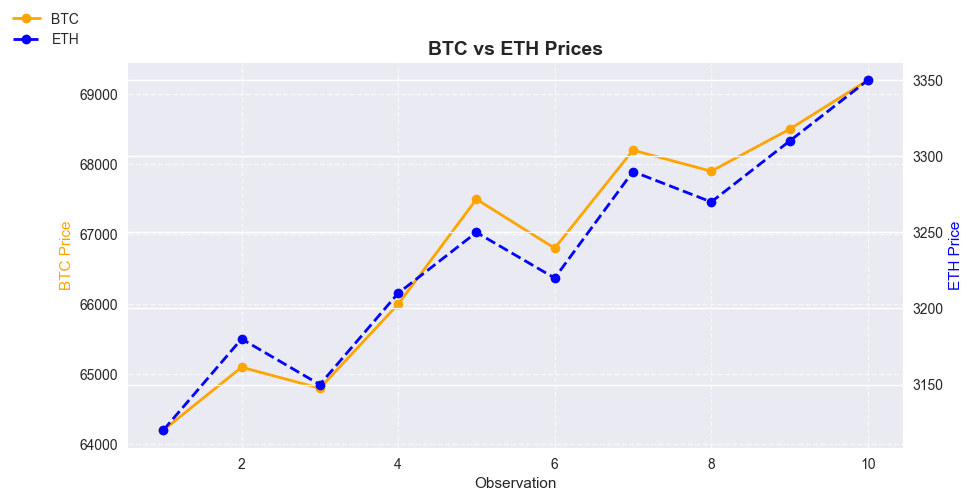

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

df = pd.read_excel("crypto.xlsx")

df["BTC (Price)"] = pd.to_numeric(df["BTC (Price)"], errors="coerce")
df["ETH(Price)"] = pd.to_numeric(df["ETH(Price)"], errors="coerce")

df = df.dropna(subset=["BTC (Price)", "ETH(Price)"])

if df["BTC (Price)"].max() < 1000:
    df["BTC (Price)"] = df["BTC (Price)"] * 1000

plt.style.use("seaborn-v0_8")

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(range(1, len(df)+1), df["BTC (Price)"], color="orange", marker="o", linewidth=2, label="BTC")
ax1.set_ylabel("BTC Price", color="orange")
ax1.set_xlabel("Observation")
ax1.grid(True, linestyle="--", alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(range(1, len(df)+1), df["ETH(Price)"], color="blue", linestyle="--", marker="o", linewidth=2, label="ETH")
ax2.set_ylabel("ETH Price", color="blue")

plt.title("BTC vs ETH Prices", fontsize=14, fontweight="bold")
fig.legend(loc="upper left")

plt.show()

## BNB Price Trend Analysis

This chart shows the daily price movement of BNB over 9 observations.

The graph demonstrates a generally positive upward trend in BNB prices during the selected period. BNB started near 600 USD and gradually increased above 700 USD by the final observation.

Compared to BTC and ETH, BNB showed stronger price growth and higher volatility. Small temporary pullbacks can be observed, but the overall direction remained bullish.

This behaviour indicates that BNB may provide higher potential returns, but it also carries higher market risk due to increased price fluctuations.

The chart helps visualize market dynamics and supports portfolio risk analysis by comparing asset behaviour across different cryptocurrencies.


In [3]:
df["BNB Price"] = pd.to_numeric(df["BNB Price"], errors="coerce")
df = df.dropna(subset=["BNB Price"])

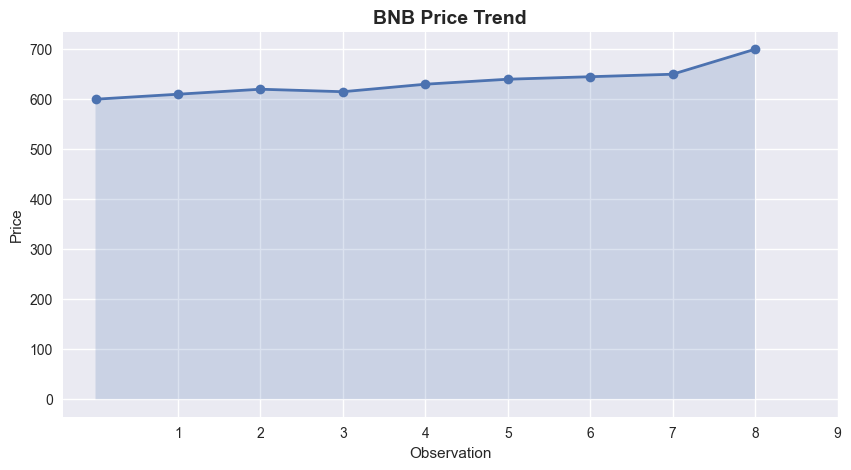

In [7]:
bnb = df["BNB Price"].astype(str).str.replace(",", ".", regex=False)
bnb = pd.to_numeric(bnb, errors="coerce").dropna()

bnb = bnb[bnb > 100]
bnb = bnb.head(10)

plt.figure(figsize=(10,5))

plt.plot(range(len(bnb)), bnb, marker="o", linewidth=2)
plt.fill_between(range(len(bnb)), bnb, alpha=0.2)

plt.title("BNB Price Trend", fontsize=14, fontweight="bold")
plt.xlabel("Observation")
plt.ylabel("Price")
plt.grid(True)

_ = plt.xticks(range(1, len(bnb)+1))

## Histogram of BTC Daily Returns

This histogram presents the distribution of BTC daily returns over the selected observation period.

Most BTC daily returns are concentrated in the positive return range between 1% and 2.5%, indicating that Bitcoin experienced mostly positive price movements during the analysed period.

The histogram also shows several negative return observations below 0%, which reflects short-term market corrections and normal cryptocurrency market volatility.

The distribution of returns demonstrates that BTC generated positive average returns while still being exposed to downside risk. This type of visualization is useful for understanding return frequency, volatility behaviour, and overall market risk characteristics.

The histogram supports portfolio risk analysis by helping identify how frequently positive and negative returns occur within the dataset.

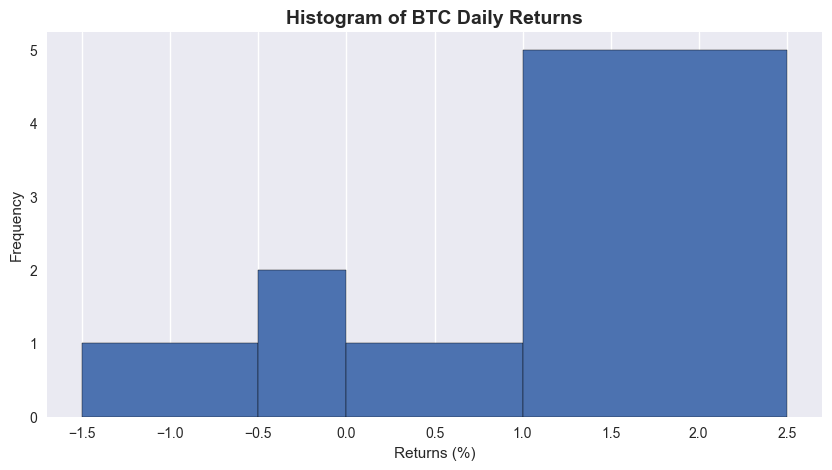

In [75]:
btc_returns = df["BTC Daily Return"].astype(str).str.replace("%", "", regex=False)
btc_returns = btc_returns.str.replace(",", ".", regex=False)
btc_returns = pd.to_numeric(btc_returns, errors="coerce").dropna()

if btc_returns.abs().max() < 1:
    btc_returns = btc_returns * 100

btc_returns = btc_returns.head(9)

plt.figure(figsize=(10,5))
plt.hist(btc_returns, bins=[-1.5, -0.5, 0, 1, 2.5], edgecolor="black")

plt.title("Histogram of BTC Daily Returns", fontsize=14, fontweight="bold")
plt.xlabel("Returns (%)")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.show()

## BTC Drawdown Analysis

This chart shows the Bitcoin drawdown over time.

Drawdown measures the decline from the previous peak price. 
It helps identify temporary losses and downside risk in the market.

The maximum drawdown in this dataset was approximately -1.04%, 
which indicates a moderate short-term decline from the peak value.

Several observations returned back to 0.00%, meaning Bitcoin reached new highs after temporary declines.

The chart demonstrates that BTC experienced small corrections, 
but the market recovered quickly, showing relatively strong momentum and resilience.

Key observations:
- 0.00% drawdown = new peak price
- Negative values = temporary market decline
- Largest decline occurred around observation 6
- Recovery after drawdown indicates bullish market behavior

In [76]:
import warnings
warnings.filterwarnings("ignore")

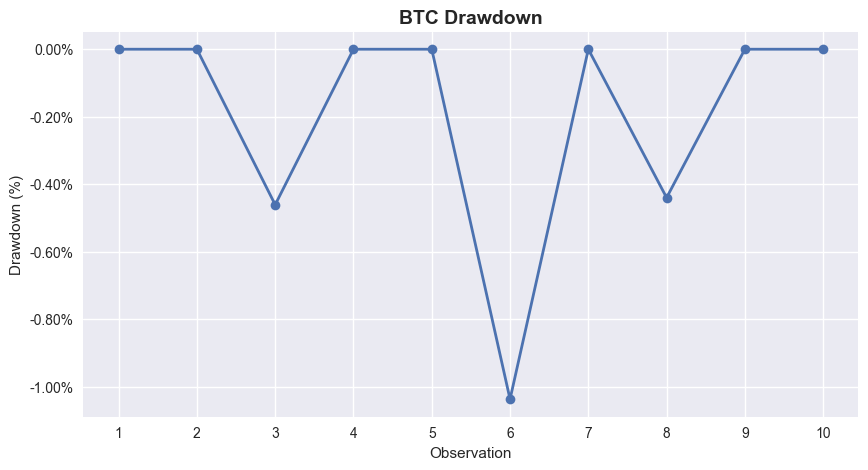

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

df2 = pd.read_excel("crypto.xlsx", sheet_name="Sheet2")
df2.columns = df2.columns.str.strip()

btc_col = "BTC(Price)" if "BTC(Price)" in df2.columns else "BTC (Price)"

btc_price = df2[btc_col].astype(str).str.replace(",", "", regex=False)
btc_price = pd.to_numeric(btc_price, errors="coerce").dropna().head(10)

btc_running_max = btc_price.cummax()
btc_drawdown = (btc_price / btc_running_max - 1) * 100

plt.figure(figsize=(10,5))
plt.plot(range(1, len(btc_drawdown) + 1), btc_drawdown, marker="o", linewidth=2)

plt.title("BTC Drawdown", fontsize=14, fontweight="bold")
plt.xlabel("Observation")
plt.ylabel("Drawdown (%)")
plt.grid(True)
plt.xticks(range(1, len(btc_drawdown) + 1))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))

plt.show()

## BTC Daily Returns Analysis

This chart shows the daily percentage returns of Bitcoin over 9 observations.

Daily return measures the percentage change in price from one day to another and helps evaluate short-term market performance and volatility.

From the chart, BTC experienced both positive and negative returns during the observed period.

Key observations:
- The highest positive return was approximately 2.27%
- The largest negative return was approximately -1.04%
- Most returns remained within a moderate range, indicating controlled short-term volatility
- Positive returns occurred more frequently than negative returns, suggesting generally bullish market behavior during this period

The sharp decline around observation 5 represents a temporary market correction, followed by a strong recovery near observation 6.

Overall, Bitcoin demonstrated relatively strong upward momentum with manageable downside risk during the analyzed period.

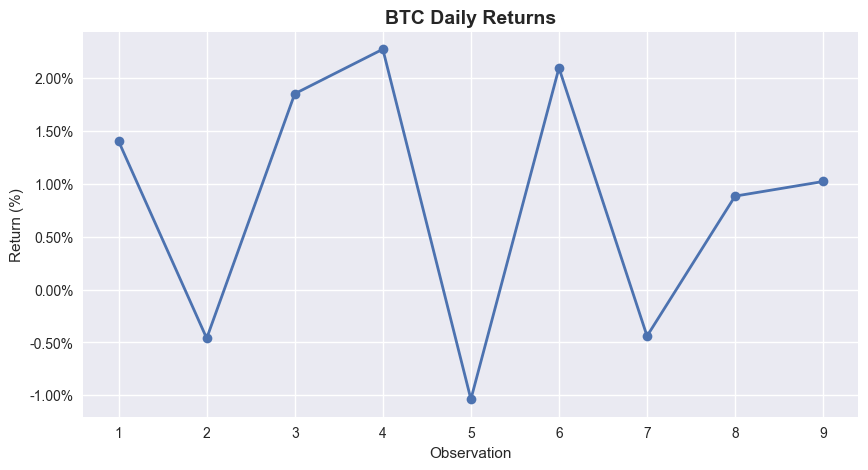

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("crypto.xlsx", sheet_name="Sheet1")

btc_returns = df["BTC Daily Return"].iloc[1:10].astype(str)
btc_returns = btc_returns.str.replace("%", "", regex=False)
btc_returns = btc_returns.str.replace(",", ".", regex=False)
btc_returns = pd.to_numeric(btc_returns, errors="coerce")

plt.figure(figsize=(10,5))

plt.plot(range(1, 10), btc_returns, marker="o", linewidth=2)

plt.title("BTC Daily Returns", fontsize=14, fontweight="bold")
plt.xlabel("Observation")
plt.ylabel("Return (%)")
plt.grid(True)
plt.xticks(range(1, 10))
plt.ylabel("Return (%)")
plt.grid(True)
plt.xticks(range(1, 10))

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.2f}%'))

plt.show()

## ETH Daily Returns Analysis

This chart presents the daily percentage returns of Ethereum over 9 observations.

Daily return analysis helps measure short-term price performance, volatility, and market direction.

From the chart and table values:

- The highest positive return was 2.17%
- The largest negative return was -0.94%
- ETH showed several strong upward movements above 1%
- Negative returns were temporary and followed by quick recoveries

The sharp declines at observations 2, 5, and 7 indicate short-term market corrections. However, the market rebounded rapidly after each decline, showing strong buying momentum.

Compared to BTC, ETH demonstrated slightly higher volatility, which is supported by the higher standard deviation value of 1.27%.

Overall, Ethereum showed strong short-term performance with moderate volatility and relatively stable recovery behavior during the analyzed period.

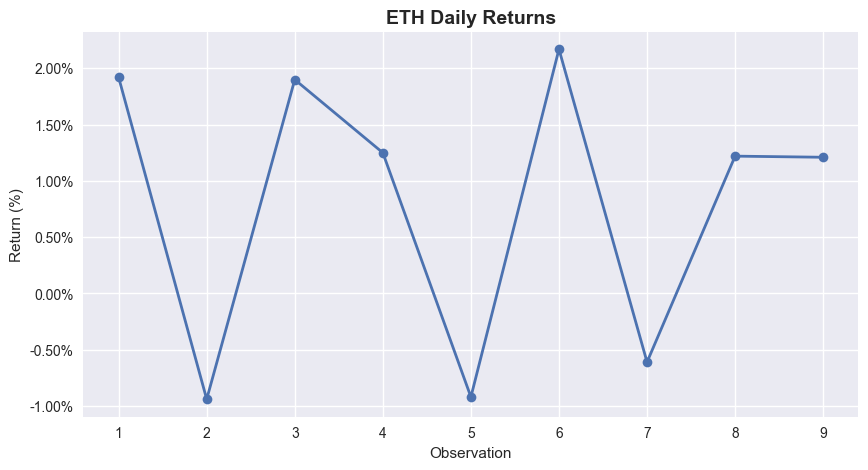

In [85]:
import matplotlib.pyplot as plt

# ETH Daily Return values from table
eth_returns = [1.92, -0.94, 1.90, 1.25, -0.92, 2.17, -0.61, 1.22, 1.21]

# Observation days
days = range(1, 10)

# Create chart
plt.figure(figsize=(10,5))

plt.plot(days, eth_returns,
         marker="o",
         linewidth=2)

# Titles
plt.title("ETH Daily Returns", fontsize=14, fontweight="bold")
plt.xlabel("Observation")
plt.ylabel("Return (%)")

# X axis 1-9
plt.xticks(days)

# Grid
plt.grid(True)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))

# Show graph
plt.show()

## Risk vs Return Analysis (Crypto Assets)

This chart compares the relationship between risk and return for BTC, ETH, and BNB.

Risk is measured using standard deviation, while return is measured using the average daily return.

From the results:

- BTC:
  - Return: 0.84%
  - Risk: 1.22%

- ETH:
  - Return: 0.80%
  - Risk: 1.27%

- BNB:
  - Return: 1.97%
  - Risk: 2.50%

The chart shows that BNB generated the highest return, but it also had the highest volatility. This means BNB offered stronger profit potential but with significantly higher risk exposure.

BTC and ETH showed lower volatility and more stable behavior compared to BNB. BTC had slightly better risk-adjusted stability than ETH because it delivered a similar return with slightly lower volatility.

The correlation matrix shows:

- BTC and ETH correlation = 0.93
- BTC and BNB correlation = -0.12
- ETH and BNB correlation = 0.05

BTC and ETH moved very closely together, indicating strong positive correlation and lower diversification benefits between them.

BNB had very weak correlation with BTC and ETH, meaning it moved more independently from the major assets. This can improve portfolio diversification and reduce concentration risk.

The covariance matrix confirms this relationship. BTC and ETH had positive covariance, while BTC and BNB showed slightly negative covariance.

Overall, the market during this period was relatively bullish because all three assets generated positive average returns. However, BNB demonstrated much higher volatility, while BTC and ETH behaved more consistently and predictably.

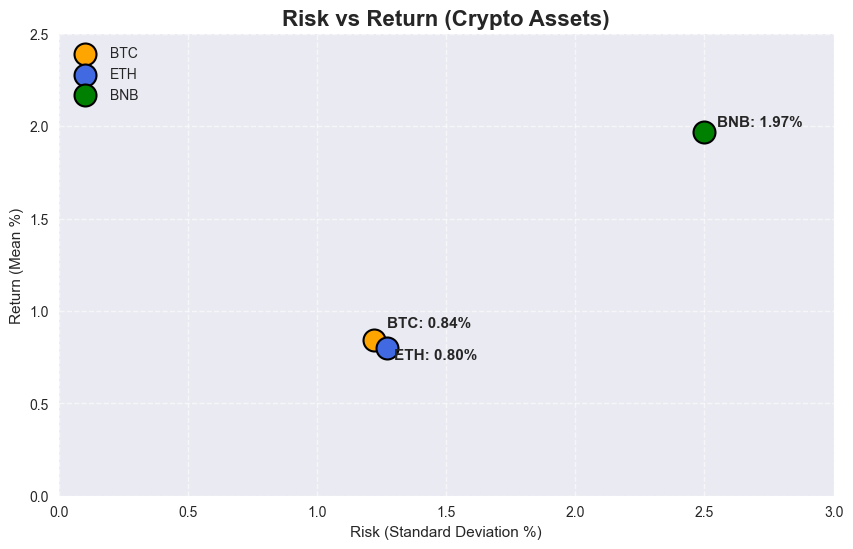

In [82]:
import matplotlib.pyplot as plt

assets = ["BTC", "ETH", "BNB"]

risk = {
    "BTC": 1.22,
    "ETH": 1.27,
    "BNB": 2.50
}

returns = {
    "BTC": 0.84,
    "ETH": 0.80,
    "BNB": 1.97
}

colors = {
    "BTC": "orange",
    "ETH": "royalblue",
    "BNB": "green"
}

plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10, 6))

for asset in assets:
    plt.scatter(
        risk[asset],
        returns[asset],
        s=250,
        color=colors[asset],
        edgecolor="black",
        linewidth=1.5,
        label=asset
    )

plt.text(1.27, 0.91, "BTC: 0.84%", fontsize=11, fontweight="bold")
plt.text(1.30, 0.74, "ETH: 0.80%", fontsize=11, fontweight="bold")
plt.text(2.55, 2.00, "BNB: 1.97%", fontsize=11, fontweight="bold")

plt.title("Risk vs Return (Crypto Assets)", fontsize=16, fontweight="bold")
plt.xlabel("Risk (Standard Deviation %)")
plt.ylabel("Return (Mean %)")

plt.xlim(0, 3.0)
plt.ylim(0, 2.5)

plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)


## Conclusion

This project analyzed the risk and return characteristics of a cryptocurrency portfolio consisting of BTC, ETH, and BNB.

The portfolio demonstrated moderate volatility and acceptable downside risk under normal market conditions.

BTC and ETH showed strong positive correlation, while BNB provided partial diversification benefits.

Backtesting results indicate that the VaR model performed within acceptable limits during the observation period.

Overall, this project demonstrates practical implementation of crypto portfolio risk management using Python, Pandas, NumPy, and statistical risk 
metrics.